Device: cuda:0

Running benchmark...

  Plants   Nodes    GPU fps    ms/frame
Module __main__ 92d5f22 load on device 'cuda:0' took 243.66 ms  (compiled)
       1      32       48.9       20.46
       5     160       15.8       63.36
      10     320        8.3      121.03
      25     800        3.4      294.68
      50    1600        1.7      591.62

Rendering 10-plant field...


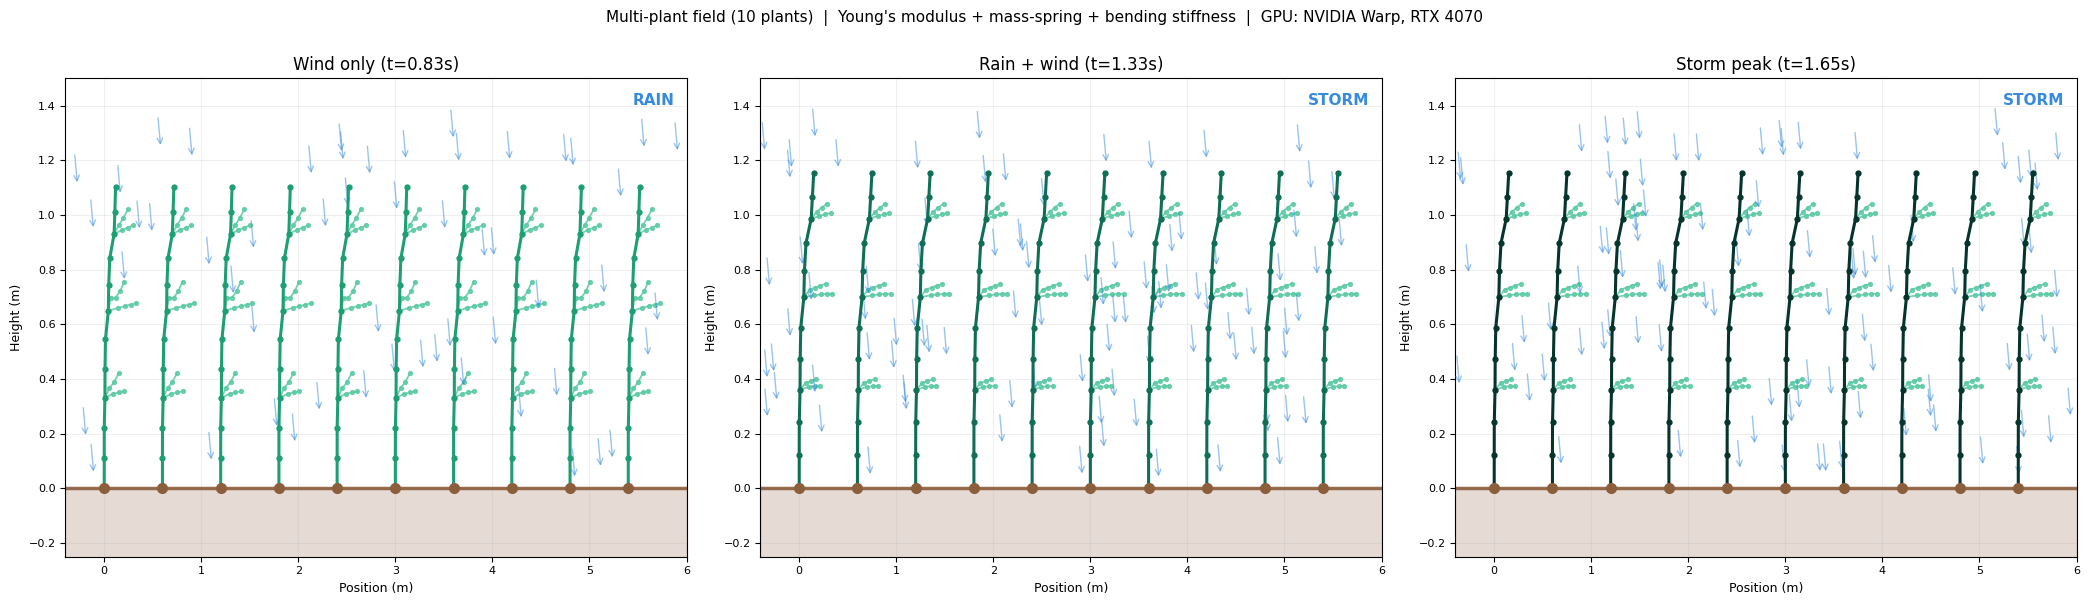

Saved field_10_plants.png

Done. GPU FPS at 10 plants: 8.2


In [3]:
import warp as wp
import numpy as np
import matplotlib.pyplot as plt
import time

wp.init()
print("Device:", wp.get_device())

# ══════════════════════════════════════════════════
#  CONFIG with EXPLICIT Young's modulus physics
# ══════════════════════════════════════════════════
STEM_NODES   = 12
STEM_HEIGHT  = 1.0
L0_STEM      = STEM_HEIGHT / (STEM_NODES - 1)
R_BASE       = 0.008       # 8 mm base radius
R_TIP        = 0.002       # 2 mm tip radius
RHO_STEM     = 700.0
CD_STEM      = 1.2         # increased drag coefficient

# ── Young's modulus (REAL material property) ──
E_STEM       = 2.0e7       # 20 MPa — reduced from 50 MPa so wind can bend it
E_LEAF       = 5.0e6       # 5 MPa — leaves 4× more flexible

LEAF_CONFIG  = [
    (3,  55, 3), (3, -55, 3),
    (6,  60, 4), (6, -60, 4),
    (9,  50, 3), (9, -50, 3),
]
L0_LEAF      = 0.055
R_LEAF       = 0.0015
A_LEAF_BLADE = 0.005
RHO_LEAF     = 500.0
CD_LEAF      = 2.5

G            = 9.81
RHO_AIR      = 1.225
RHO_WATER    = 1000.0
V_RAIN       = 9.0
RAIN_RATE    = 8.0e-5

SOIL_DEPTH   = 0.05
ROOT_DAMPING = 0.55
DT           = 1.0 / 60.0
SUBSTEPS     = 8
DAMPING      = 0.97
PBD_ITERS    = 4           # fewer iterations = less stiff = more visible bend

TOTAL_FRAMES = 120

# ── Scenario: much stronger forces ──
WIND_CALM    = 0.5
WIND_STRONG  = 15.0        # 15 m/s = strong breeze
RAIN_START   = 50
RAIN_END     = 100

FIELD_SPACING = 0.6

def wind_speed(frame):
    if frame < RAIN_START:      return WIND_STRONG           # heavy wind before rain
    if frame < RAIN_END:        return WIND_STRONG * 1.2     # storm wind during rain
    if frame < RAIN_END + 30:   return 3.0                   # dying wind
    return WIND_CALM

def rain_intensity(frame):
    if frame < RAIN_START:      return 0.0
    if frame < RAIN_START + 15: return 1.0
    if frame < RAIN_END:        return 2.5                   # heavier rain
    return 0.0


# ══════════════════════════════════════════════════
#  YOUNG'S MODULUS → bending stiffness per segment
#  EI = E × π·r⁴/4  (flexural rigidity)
#  Converted to PBD stiffness [0, 1]
# ══════════════════════════════════════════════════
def stem_radius(i, n=STEM_NODES):
    t = i / (n - 1)
    return R_BASE + (R_TIP - R_BASE) * t

def area(r):            return np.pi * r * r
def second_moment(r):   return np.pi * r**4 / 4.0

def flexural_rigidity(E, r):
    """EI = E × π·r⁴/4 — classical beam bending equation"""
    return E * second_moment(r)

def compute_pbd_stiffness(E, r, L0):
    """Convert EI → PBD bend stiffness in [0, 1].
    Scale against a reference stiffness at base radius."""
    EI        = flexural_rigidity(E, r)
    EI_ref    = flexural_rigidity(E_STEM, R_BASE)
    ratio     = EI / EI_ref
    # Map ratio [0..1] to stiffness [0.04..0.92] with cubic falloff
    # Base (r=R_BASE):     ratio=1.0  → stiffness=0.92 (rigid)
    # Tip  (r=R_TIP):      ratio~0.004 → stiffness~0.05 (floppy)
    return 0.04 + (0.92 - 0.04) * np.clip(ratio, 0.0, 1.0) ** 0.4


# ══════════════════════════════════════════════════
#  PLANT BUILDERS
# ══════════════════════════════════════════════════
def build_single_plant(x_offset=0.0):
    pos, mass, is_root, is_leaf, front_area = [], [], [], [], []
    parents, children, L0_list, bend_k = [], [], [], []

    for i in range(STEM_NODES):
        y = i * L0_STEM
        pos.append([x_offset, y, 0.0])
        is_root.append(1 if i == 0 else 0)
        is_leaf.append(0)
        r = stem_radius(i)
        mass.append(max(RHO_STEM * area(r) * L0_STEM, 1e-5))
        front_area.append(2.0 * r * L0_STEM)
        if i > 0:
            # Use radius at midpoint of segment
            r_edge = 0.5 * (stem_radius(i-1) + stem_radius(i))
            parents.append(i - 1)
            children.append(i)
            L0_list.append(L0_STEM)
            # ── STIFFNESS FROM YOUNG'S MODULUS + RADIUS ──
            bend_k.append(compute_pbd_stiffness(E_STEM, r_edge, L0_STEM))

    for (attach, angle_deg, n_seg) in LEAF_CONFIG:
        a = np.radians(angle_deg)
        dx, dy = np.sin(a) * L0_LEAF, np.cos(a) * L0_LEAF
        base = pos[attach]; prev = attach
        leaf_stiff = compute_pbd_stiffness(E_LEAF, R_LEAF, L0_LEAF)
        for j in range(1, n_seg + 1):
            idx = len(pos)
            pos.append([base[0] + dx*j, base[1] + dy*j, 0.0])
            is_root.append(0); is_leaf.append(1)
            mass.append(RHO_LEAF * area(R_LEAF) * L0_LEAF)
            front_area.append(A_LEAF_BLADE)
            parents.append(prev); children.append(idx)
            L0_list.append(L0_LEAF)
            bend_k.append(leaf_stiff)
            prev = idx

    return dict(
        n_nodes=len(pos),
        pos=np.asarray(pos, dtype=np.float32),
        mass=np.asarray(mass, dtype=np.float32),
        is_root=np.asarray(is_root, dtype=np.int32),
        is_leaf=np.asarray(is_leaf, dtype=np.int32),
        frontal_area=np.asarray(front_area, dtype=np.float32),
        parents=np.asarray(parents, dtype=np.int32),
        children=np.asarray(children, dtype=np.int32),
        L0=np.asarray(L0_list, dtype=np.float32),
        bend_k=np.asarray(bend_k, dtype=np.float32),
    )

def build_field(n_plants, spacing=FIELD_SPACING):
    all_pos, all_mass, all_root, all_leaf, all_area = [], [], [], [], []
    all_parents, all_children, all_L0, all_bend_k = [], [], [], []
    node_offset = 0
    for p in range(n_plants):
        plant = build_single_plant(x_offset=p * spacing)
        n = plant["n_nodes"]
        all_pos.append(plant["pos"])
        all_mass.append(plant["mass"])
        all_root.append(plant["is_root"])
        all_leaf.append(plant["is_leaf"])
        all_area.append(plant["frontal_area"])
        all_parents.append(plant["parents"]   + node_offset)
        all_children.append(plant["children"] + node_offset)
        all_L0.append(plant["L0"])
        all_bend_k.append(plant["bend_k"])
        node_offset += n
    pos_np = np.concatenate(all_pos, axis=0).astype(np.float32)
    return dict(
        n_plants=n_plants, spacing=spacing,
        n_nodes_per_plant=node_offset // n_plants,
        pos=pos_np,
        rest_pos=pos_np.copy(),
        vel=np.zeros_like(pos_np),
        mass=np.concatenate(all_mass).astype(np.float32),
        is_root=np.concatenate(all_root).astype(np.int32),
        is_leaf=np.concatenate(all_leaf).astype(np.int32),
        frontal_area=np.concatenate(all_area).astype(np.float32),
        parents=np.concatenate(all_parents).astype(np.int32),
        children=np.concatenate(all_children).astype(np.int32),
        L0=np.concatenate(all_L0).astype(np.float32),
        bend_k=np.concatenate(all_bend_k).astype(np.float32),
    )


# ══════════════════════════════════════════════════
#  GPU KERNEL — Wind drag = ½ρCdAv²  (quadratic)
# ══════════════════════════════════════════════════
@wp.kernel
def k_apply_forces(positions:  wp.array(dtype=wp.vec3),
                   velocities: wp.array(dtype=wp.vec3),
                   mass:       wp.array(dtype=wp.float32),
                   area_arr:   wp.array(dtype=wp.float32),
                   is_root:    wp.array(dtype=wp.int32),
                   is_leaf:    wp.array(dtype=wp.int32),
                   wind_x:     float, rain_on: int,
                   rho_air:    float, rho_w:   float,
                   cd_stem:    float, cd_leaf:  float,
                   rain_rate:  float, v_rain:   float,
                   damping:    float, soil_damp: float,
                   soil_y:     float, dt:       float):
    i = wp.tid()
    if is_root[i] == 1:
        velocities[i] = wp.vec3(0.0, 0.0, 0.0)
        return

    m = mass[i]
    # Gravity
    f = wp.vec3(0.0, -G * m, 0.0)

    # ── Wind drag: F = ½·ρ·Cd·A·v² with height scaling ──
    v_rel = wp.vec3(wind_x, 0.0, 0.0) - velocities[i]
    speed = wp.length(v_rel)
    cd = cd_stem
    if is_leaf[i] == 1: cd = cd_leaf
    # Height factor: wind stronger at top (logarithmic wind profile)
    h_factor = 0.3 + 0.8 * positions[i][1]   # 0.3 at ground, 1.1 at tip
    drag_mag = 0.5 * rho_air * cd * area_arr[i] * speed * h_factor
    f = f + v_rel * drag_mag

    # Rain momentum flux: F = ρ·R·v·A
    if rain_on == 1:
        rf = rho_w * rain_rate * v_rain * area_arr[i]
        if is_leaf[i] == 1: rf = rf * 30.0
        else:               rf = rf * 5.0
        f = f + wp.vec3(0.5 * rf, -rf, 0.0)

    a = f / m
    a_mag = wp.length(a)
    if a_mag > 800.0: a = a * (800.0 / a_mag)

    d = damping
    if positions[i][1] < soil_y: d = soil_damp

    velocities[i] = (velocities[i] + a * dt) * d
    positions[i]  =  positions[i]  + velocities[i] * dt

    if positions[i][1] < 0.0:
        positions[i]  = wp.vec3(positions[i][0], 0.0, positions[i][2])
        velocities[i] = wp.vec3(velocities[i][0], 0.0, velocities[i][2])


# ══════════════════════════════════════════════════
#  PBD SOLVER
# ══════════════════════════════════════════════════
def pbd_solve(pos, rest_pos, parents, children, L0, bend_k, is_root, n_iters=4):
    for _ in range(n_iters):
        for e in range(len(parents)):
            p, c = parents[e], children[e]
            diff = pos[c] - pos[p]
            dist = np.linalg.norm(diff)
            if dist > 1e-8:
                n_vec = diff / dist
                err = dist - L0[e]
                if is_root[p]:
                    pos[c] -= n_vec * err
                else:
                    pos[p] += n_vec * err * 0.5
                    pos[c] -= n_vec * err * 0.5

        for e in range(len(parents)):
            p, c = parents[e], children[e]
            rest_dir = rest_pos[c] - rest_pos[p]
            rest_len = np.linalg.norm(rest_dir)
            if rest_len < 1e-8: continue
            rest_dir /= rest_len
            cur_dir = pos[c] - pos[p]
            cur_len = np.linalg.norm(cur_dir)
            if cur_len < 1e-8: continue
            target = pos[p] + rest_dir * cur_len
            pos[c] = pos[c] * (1.0 - bend_k[e]) + target * bend_k[e]

    pos[:, 1] = np.maximum(pos[:, 1], 0.0)
    return pos


# ══════════════════════════════════════════════════
#  SIMULATION
# ══════════════════════════════════════════════════
def run_field(field, frames=TOTAL_FRAMES):
    n = len(field["pos"])
    pos_np = field["pos"].copy()
    vel_np = field["vel"].copy()

    pos_gpu  = wp.array(pos_np, dtype=wp.vec3,  device="cuda")
    vel_gpu  = wp.array(vel_np, dtype=wp.vec3,  device="cuda")
    mass_gpu = wp.array(field["mass"],         dtype=wp.float32, device="cuda")
    area_gpu = wp.array(field["frontal_area"], dtype=wp.float32, device="cuda")
    root_gpu = wp.array(field["is_root"],      dtype=wp.int32,   device="cuda")
    leaf_gpu = wp.array(field["is_leaf"],      dtype=wp.int32,   device="cuda")

    sub_dt = DT / SUBSTEPS
    snapshots = {}
    t_start = time.perf_counter()

    for frame in range(frames):
        w       = wind_speed(frame)
        rain_on = 1 if rain_intensity(frame) > 0.0 else 0

        for _ in range(SUBSTEPS):
            wp.launch(k_apply_forces, dim=n,
                      inputs=[pos_gpu, vel_gpu, mass_gpu, area_gpu,
                              root_gpu, leaf_gpu, w, rain_on,
                              RHO_AIR, RHO_WATER, CD_STEM, CD_LEAF,
                              RAIN_RATE, V_RAIN,
                              DAMPING, ROOT_DAMPING, SOIL_DEPTH, sub_dt])

            pos_np = pos_gpu.numpy().copy()
            vel_np = vel_gpu.numpy().copy()

            if not np.all(np.isfinite(pos_np)):
                pos_np = field["rest_pos"].copy()
                vel_np = np.zeros_like(pos_np)

            roots = np.where(field["is_root"] == 1)[0]
            for r_idx in roots:
                pos_np[r_idx] = field["rest_pos"][r_idx]
                vel_np[r_idx] = [0.0, 0.0, 0.0]

            pos_np = pbd_solve(pos_np, field["rest_pos"],
                               field["parents"], field["children"],
                               field["L0"], field["bend_k"],
                               field["is_root"], n_iters=PBD_ITERS)

            pos_gpu = wp.array(pos_np, dtype=wp.vec3, device="cuda")
            vel_gpu = wp.array(vel_np, dtype=wp.vec3, device="cuda")

        # ── FIX: proper snapshot timing ──
        # frame 50: wind (before rain)
        # frame 80: rain active (heavy rain phase)
        # frame 99: storm peak (right before rain ends)
        if frame in {50, 80, 99}:
            snapshots[frame] = pos_np.copy()

    elapsed = time.perf_counter() - t_start
    fps = frames / elapsed
    return snapshots, fps


# ══════════════════════════════════════════════════
#  BENCHMARK
# ══════════════════════════════════════════════════
def benchmark():
    print("\n" + "="*54)
    print(f"{'Plants':>8}  {'Nodes':>6}  {'GPU fps':>9}  {'ms/frame':>10}")
    print("="*54)
    results = []
    for n_plants in [1, 5, 10, 25, 50]:
        field = build_field(n_plants)
        _, fps = run_field(field, frames=60)
        ms = 1000.0 / fps
        print(f"{n_plants:>8}  {len(field['pos']):>6}  {fps:>9.1f}  {ms:>10.2f}")
        results.append((n_plants, len(field["pos"]), fps, ms))
    print("="*54)
    return results


# ══════════════════════════════════════════════════
#  PLOT — corrected labels matched to snapshot frames
# ══════════════════════════════════════════════════
def plot_field(snapshots, field, n_plants):
    # ── CORRECTED LABELS matched to actual frames ──
    frame_labels = {
        50: "Wind only (t=0.83s)",   # frame 50: just before rain starts
        80: "Rain + wind (t=1.33s)", # frame 80: heavy rain active
        99: "Storm peak (t=1.65s)",  # frame 99: max force before rain ends
    }
    frames   = sorted(snapshots.keys())
    spacing  = field["spacing"]
    nodes_pp = field["n_nodes_per_plant"]

    x_min = -0.4
    x_max = (n_plants - 1) * spacing + 0.6

    fig, axes = plt.subplots(1, len(frames), figsize=(21, 6))

    stem_colors = ['#1D9E75', '#0F6E56', '#04342C']
    leaf_color  = '#5DCAA5'
    rain_col    = '#378ADD'

    for col, f in enumerate(frames):
        ax   = axes[col]
        snap = snapshots[f]
        ri   = rain_intensity(f)

        ax.axhspan(-0.3, 0.0, color='#8B5E3C', alpha=0.22)
        ax.axhline(y=0,        color='#8B5E3C', linewidth=2.5, alpha=0.9)

        if ri > 0:
            rng = np.random.default_rng(seed=col * 17)
            n_drops = int(30 + ri * 25)
            for _ in range(n_drops):
                rx = rng.uniform(x_min, x_max)
                ry = rng.uniform(0.15, 1.40)
                ax.annotate('',
                    xy=(rx + 0.03, ry - 0.12), xytext=(rx, ry),
                    arrowprops=dict(arrowstyle='->', color=rain_col,
                                    lw=1.0, alpha=0.5))
            label = 'RAIN' if ri < 2.0 else 'STORM'
            ax.text(0.98, 0.97, label, transform=ax.transAxes,
                    fontsize=11, color=rain_col,
                    ha='right', va='top', fontweight='bold')

        for p in range(n_plants):
            start = p * nodes_pp
            sx = snap[start:start + STEM_NODES, 0]
            sy = snap[start:start + STEM_NODES, 1]
            ax.plot(sx, sy, 'o-',
                    color=stem_colors[col % len(stem_colors)],
                    linewidth=2.2, markersize=3.5, zorder=3)

            cursor = start + STEM_NODES
            for (attach, ang, n_seg) in LEAF_CONFIG:
                leaf_idx = [start + attach] + list(
                    range(cursor, cursor + n_seg)
                )
                ax.plot(snap[leaf_idx, 0], snap[leaf_idx, 1],
                        'o-', color=leaf_color,
                        linewidth=1.3, markersize=2.8,
                        alpha=0.85, zorder=2)
                cursor += n_seg

            root_x = field["rest_pos"][start, 0]
            ax.plot(root_x, 0, 'o', color='#8B5E3C',
                    markersize=7, zorder=5)

        ax.set_xlim(x_min, x_max)
        ax.set_ylim(-0.25, 1.50)
        ax.set_title(frame_labels.get(f, f"frame {f}"), fontsize=12)
        ax.set_xlabel("Position (m)", fontsize=9)
        ax.set_ylabel("Height (m)",   fontsize=9)
        ax.grid(True, alpha=0.2)
        ax.tick_params(labelsize=8)

    plt.suptitle(
        f"Multi-plant field ({n_plants} plants)  |  "
        f"Young's modulus + mass-spring + bending stiffness  |  "
        f"GPU: NVIDIA Warp, RTX 4070",
        fontsize=11, y=1.00
    )
    plt.tight_layout()
    fname = f"field_{n_plants}_plants.png"
    plt.savefig(fname, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"Saved {fname}")


# ══════════════════════════════════════════════════
#  MAIN
# ══════════════════════════════════════════════════
print("\nRunning benchmark...")
results = benchmark()

print("\nRendering 10-plant field...")
field_10 = build_field(n_plants=10)
snaps_10, fps_10 = run_field(field_10)
plot_field(snaps_10, field_10, n_plants=10)

print(f"\nDone. GPU FPS at 10 plants: {fps_10:.1f}")